# Course Design Demo

本 Notebook 展示“面向本地生活商户的商品级广告增长决策 Agent”。项目聚焦数字经济/平台经济中的本地生活商户增长问题：商户希望提升曝光、点击、转化和订单；POI 级广告难以精确承接高意向搜索；商品级广告需要解决主推品选择、Query-SKU 匹配、出价和 ROI 风险控制。

所有数据均为 synthetic demo data，不涉及真实平台、真实商户、真实用户或敏感业务信息。

## 运行环境初始化

初始化 SQLite demo database，并加载 pandas / matplotlib 展示后续结果。

In [1]:
from pathlib import Path
import json
import sys

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "app").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

from app.agent.graph import run_agent
from app.db.init_db import initialize_database

initialize_database()
DATA_DIR = PROJECT_ROOT / "data"
print("project_root=<repo_root>")
print("data_dir=./data")

project_root=<repo_root>
data_dir=./data


## 数据介绍

读取经营归因与商品级广告相关 CSV。这里展示每张表的行列规模，便于说明 demo 数据范围。

In [2]:
table_names = [
    "products",
    "orders",
    "traffic",
    "reviews",
    "campaigns",
    "local_ad_sku_candidates",
    "query_sku_recall",
    "ad_bid_experiments",
    "poi_level_ads_baseline",
]
tables = {name: pd.read_csv(DATA_DIR / f"{name}.csv") for name in table_names}
shape_df = pd.DataFrame(
    [{"table": name, "rows": df.shape[0], "columns": df.shape[1]} for name, df in tables.items()]
)
display(shape_df)

,table,rows,columns
0,products,5,5
1,orders,2196,8
2,traffic,1220,7
3,reviews,280,5
4,campaigns,4,6
5,local_ad_sku_candidates,15,17
6,query_sku_recall,24,9
7,ad_bid_experiments,10,15
8,poi_level_ads_baseline,9,13


In [3]:
candidate_preview = tables["local_ad_sku_candidates"].head(8)
display(candidate_preview)

,merchant_id,poi_id,product_id,product_name,category,service_type,price,cvr,gmv_share,pcvr,historical_roi,margin_rate,available_slots,rating,refund_rate,keyword_coverage,is_current_bestseller
0,M001,POI001,P1001,水光补水体验套餐,丽人医美,皮肤管理,399,0.1809,0.32,0.065,3.8,0.28,120,4.4,0.085,0.76,True
1,M001,POI001,P1002,小气泡清洁护理,丽人医美,皮肤管理,199,0.1540,0.21,0.052,3.3,0.35,180,4.5,0.041,0.68,True
2,M001,POI001,P1003,基础皮肤检测,丽人医美,咨询体验,49,0.2260,0.08,0.081,2.1,0.18,300,4.2,0.025,0.44,False
3,M001,POI001,P1004,胶原修护护理套餐,丽人医美,皮肤管理,299,0.1390,0.18,0.047,3.0,0.31,90,4.1,0.063,0.59,False
4,M002,POI002,P2001,日式美甲单色套餐,美甲美睫,美甲,128,0.1910,0.28,0.072,4.1,0.42,210,4.7,0.018,0.81,True
5,M002,POI002,P2002,美睫自然款套餐,美甲美睫,美睫,168,0.1330,0.17,0.046,3.2,0.39,160,4.6,0.022,0.64,False
6,M002,POI002,P2003,延长甲设计款套餐,美甲美睫,美甲,238,0.1210,0.20,0.041,2.9,0.37,80,4.3,0.044,0.73,False
7,M003,POI003,P3001,双人烤肉套餐,餐饮团购,正餐,188,0.1180,0.36,0.039,3.6,0.25,500,4.3,0.035,0.72,True


## 经营归因 Demo

该 case 保留原项目能力：Agent 识别经营诊断意图，调用 metrics / review / campaign / RAG，并生成可追溯报告。下面展示一条完整 final_answer 和 trace_id。

In [4]:
business_result = run_agent("商品 P1001 最近 GMV 为什么下降？")
print("intent:", business_result["intent"])
print("trace_id:", business_result["trace_id"])
print("tool_result_keys:", sorted(business_result["tool_results"].keys()))
print("\n完整 final_answer:\n")
print(business_result["final_answer"])

intent: business_diagnosis
trace_id: 69bfdc6e-2c5b-4d9b-80a1-496c5d90daf8
tool_result_keys: ['baseline_aov', 'baseline_channel_breakdown', 'baseline_gmv', 'baseline_refund', 'baseline_traffic', 'campaign_analysis', 'campaign_context_comparison', 'campaign_participation', 'current_aov', 'current_channel_breakdown', 'current_gmv', 'current_refund', 'current_traffic', 'evidence_alignment', 'gmv_contribution', 'gmv_decomposition', 'graph_routing', 'intent_router', 'llm_provider', 'period_comparison', 'product_basic_info', 'prompt_guard', 'rag_search', 'recommendation_result', 'review_analysis', 'review_period_comparison', 'review_topic_analysis', 'security', 'tool_policy']

完整 final_answer:

## 问题概述
用户问题关注“商品 P1001 最近 GMV 为什么下降？”。当前识别对象为 P1001（水光补水体验套餐），分析口径为 2026-04-01 至 2026-04-30，对比基准期 2026-03-01 至 2026-03-31。从工具计算看，4 月 GMV 为 63077.91，低于 3 月的 198877.56，需要按流量、转化、客单价和售后共同归因。

## 指标拆解
- GMV：当前 63077.91，基准 198877.56，变化 -135799.65，变化率 -68.28%。
- 点击率 CTR：当前 5.18%，基准 8.14%，变化 -36.33%。其中 search

## 主推品挖掘 Demo

商户 M001 的主推品挖掘由 `product_ad_tool` 完成，核心字段包括 CVR、GMV 占比、PCVR、历史 ROI、退款率和 Product Growth Score。

In [5]:
sku_result = run_agent("商户 M001 应该优先推哪些商品做搜索广告？")
sku_candidates = sku_result["tool_results"]["product_ad"]["sku_mining"]["candidates"]
sku_df = pd.DataFrame(sku_candidates)
display(sku_df[["rank", "product_id", "product_name", "cvr", "gmv_share", "pcvr", "historical_roi", "refund_rate", "product_growth_score"]])
print("trace_id:", sku_result["trace_id"])

,rank,product_id,product_name,cvr,gmv_share,pcvr,historical_roi,refund_rate,product_growth_score
0,1,P1001,水光补水体验套餐,0.1809,0.32,0.065,3.8,0.085,0.571
1,2,P1003,基础皮肤检测,0.2260,0.08,0.081,2.1,0.025,0.512
2,3,P1002,小气泡清洁护理,0.1540,0.21,0.052,3.3,0.041,0.383
3,4,P1004,胶原修护护理套餐,0.1390,0.18,0.047,3.0,0.063,0.112


trace_id: 98016cf8-50a1-42d3-9666-88592871d705


In [6]:
product_ad_tool_results = sku_result["tool_results"]["product_ad"]
print(json.dumps(product_ad_tool_results, ensure_ascii=False, indent=2)[:4000])

{
  "intent": "product_ad_strategy",
  "entities": {
    "product_id": "",
    "merchant_id": "M001",
    "poi_id": null,
    "recall_query": "广告",
    "target_roi": 3.0,
    "bid_multiplier": 1.0,
    "budget_limited": false,
    "refund_risk_focus": false,
    "comparison_focus": false
  },
  "sku_mining": {
    "ok": true,
    "merchant_id": "M001",
    "top_k": 5,
    "candidates": [
      {
        "rank": 1,
        "product_id": "P1001",
        "product_name": "水光补水体验套餐",
        "merchant_id": "M001",
        "poi_id": "POI001",
        "category": "丽人医美",
        "service_type": "皮肤管理",
        "price": 399.0,
        "cvr": 0.1809,
        "gmv_share": 0.32,
        "pcvr": 0.065,
        "historical_roi": 3.8,
        "margin_rate": 0.28,
        "available_slots": 120,
        "rating": 4.4,
        "refund_rate": 0.085,
        "keyword_coverage": 0.76,
        "is_current_bestseller": true,
        "product_growth_score": 0.571,
        "key_reasons": [
          "GMV占比较

## 出价与 ROI 守护 Demo

出价区间由 PCVR、price、margin_rate 和 target ROI 计算；加价模拟会按用户目标 ROI 输出 pass / watch / risk 与 guardrail_action。

In [7]:
bid_range_result = run_agent("目标 ROI 为 4.5 时，P1001 加价 20% 还安全吗？")
bid_payload = bid_range_result["tool_results"]["product_ad"]
bid_range = bid_payload["bid_range"]
bid_simulation = bid_payload["bid_simulation"]
bid_df = pd.DataFrame([bid_range])
sim_df = pd.DataFrame([bid_simulation])
display(bid_df[["product_id", "pcvr", "price", "target_roi", "max_cpc_by_revenue_roi", "max_cpc_by_profit_roi", "recommended_cpc_range", "bid_strategy", "risk_flags"]])
display(sim_df[["product_id", "requested_bid_multiplier", "target_roi", "roi", "roi_gap", "roi_status", "guardrail_action", "risk_note"]])
print("trace_id:", bid_range_result["trace_id"])

,product_id,pcvr,price,target_roi,max_cpc_by_revenue_roi,max_cpc_by_profit_roi,recommended_cpc_range,bid_strategy,risk_flags
0,P1001,0.065,399.0,4.5,5.76,1.61,"[0.97, 1.78]",conservative,"[退款率偏高，需要关注履约和售后, 历史 ROI 低于目标 ROI，出价应更谨慎]"


,product_id,requested_bid_multiplier,target_roi,roi,roi_gap,roi_status,guardrail_action,risk_note
0,P1001,1.2,4.5,3.43,-1.07,risk,down_bid,ROI 低于目标 ROI，不建议继续加价。


trace_id: cb3e6efa-e8fc-434b-8783-7cd4175dfa8c


## Query-SKU 召回 Demo

Query-SKU 召回先使用 exact demo rows；未命中时使用 deterministic TF-IDF fallback，并在结果中显式标注不确定性。

In [8]:
recall_result = run_agent("用户搜索 水光补水 时，应该召回哪些商品，为什么？")
recall_payload = recall_result["tool_results"]["product_ad"]
recall_df = pd.DataFrame(recall_payload["query_recall"]["results"])
rank_df = pd.DataFrame(recall_payload["ranked_candidates"]["ranked_candidates"])
display(recall_df[["product_id", "product_name", "recall_path", "recall_score", "matched_terms"]])
display(rank_df[["rank", "product_id", "final_score", "candidate_source", "recall_matched", "recall_path", "recommendation"]])
print("trace_id:", recall_result["trace_id"])

,product_id,product_name,recall_path,recall_score,matched_terms
0,P1001,水光补水体验套餐,keyword_inverted,0.94,水光|补水
1,P1002,小气泡清洁护理,query_expansion,0.71,补水|清洁|皮肤管理
2,P1003,基础皮肤检测,vector_match,0.58,皮肤|检测|护理


,rank,product_id,final_score,candidate_source,recall_matched,recall_path,recommendation
0,1,P1001,0.719,global_recall,True,keyword_inverted,可作为候选，但需先处理风险或小流量验证
1,2,P1002,0.509,global_recall,True,query_expansion,适合作为商品级广告主推品
2,3,P1003,0.415,global_recall,True,vector_match,可作为候选，但需先处理风险或小流量验证


trace_id: 615a68ee-8fd5-483d-9079-3404ab9536df


In [9]:
hard_recall_result = run_agent("商户 M001 下，用户搜索 美甲款式 时，应该召回哪些商品？")
hard_ranked = hard_recall_result["tool_results"]["product_ad"]["ranked_candidates"]
print(json.dumps({
    "ranked_candidates": hard_ranked.get("ranked_candidates"),
    "fallback_candidates": hard_ranked.get("fallback_candidates", [])[:3],
    "uncertainty_note": hard_ranked.get("uncertainty_note"),
}, ensure_ascii=False, indent=2))

{
  "ranked_candidates": [],
  "fallback_candidates": [
    {
      "product_id": "P1001",
      "product_name": "水光补水体验套餐",
      "merchant_id": "M001",
      "final_score": 0.214,
      "score_version": "product_ad_score_v2",
      "candidate_source": "merchant_fallback",
      "recall_matched": false,
      "uncertainty_note": "非 Query 直接召回，仅作为商户候选补充。",
      "score_breakdown": {
        "product_growth_score": 0.571,
        "recall_score": 0.0,
        "roi_score": 1.0,
        "keyword_coverage_score": 1.0,
        "refund_risk_penalty": 0.043,
        "non_recall_penalty": 0.2
      },
      "recall_path": null,
      "matched_terms": null,
      "recommendation": "不建议作为优先加价主推品",
      "risk_flags": [
        "退款率偏高，需要关注履约和售后"
      ],
      "rank": 1
    },
    {
      "product_id": "P1002",
      "product_name": "小气泡清洁护理",
      "merchant_id": "M001",
      "final_score": 0.095,
      "score_version": "product_ad_score_v2",
      "candidate_source": "merchant_fallback",
      

## POI 级广告 vs 商品级广告 Demo

对比表展示 synthetic baseline 中 POI 级广告、商品级广告和商品级广告+智能调价的 CTR、CVR、订单与 ROI。

In [10]:
compare_result = run_agent("商户 M001 从门店级广告升级到商品级广告，CTR、CVR 和 ROI 有什么变化？")
compare_df = pd.DataFrame(compare_result["tool_results"]["product_ad"]["comparison"]["comparison"])
display(compare_df[["campaign_type", "impressions", "clicks", "orders", "ctr", "cvr", "roi", "notes"]])

,campaign_type,impressions,clicks,orders,ctr,cvr,roi,notes
0,poi_level,52000,3380,372,0.0650,0.1101,3.30,门店级广告覆盖泛皮肤管理需求
1,product_level,41000,3567,515,0.0870,0.1444,3.63,商品级广告承接水光补水和小气泡等明确服务需求
2,product_level_with_smart_bid,43000,3978,612,0.0925,0.1538,3.81,智能调价限制低 ROI 流量并保留高意向 Query


## Eval 实验

运行 full_agent eval，并用 DataFrame 展示核心 overall metrics。

In [11]:
from evals.run_eval import run_evaluations

eval_result = run_evaluations(mode="full_agent")
eval_metrics_df = pd.DataFrame([eval_result["overall_metrics"]]).T.rename(columns={0: "value"})
print("case_count:", eval_result["case_count"])
display(eval_metrics_df.loc[[
    "avg_score",
    "intent_accuracy",
    "evidence_hit_rate",
    "avg_bid_guardrail",
    "avg_sku_recall_fields",
    "avg_claim_evidence_alignment",
    "avg_reflection_quality",
]])

case_count: 44


,value
avg_score,0.974587
intent_accuracy,0.977273
evidence_hit_rate,1.000000
avg_bid_guardrail,1.000000
avg_sku_recall_fields,1.000000
avg_claim_evidence_alignment,1.000000
avg_reflection_quality,0.485606


## Ablation 实验

运行课程消融实验，并用 DataFrame 展示不同模式的分数、证据命中和延迟。

In [12]:
from evals.run_ablation import run_ablation

ablation_result = run_ablation()
ablation_df = pd.DataFrame(ablation_result["overall_metrics_by_mode"]).T
display(ablation_df[["avg_score", "evidence_hit_rate", "avg_bid_guardrail", "avg_sku_recall_fields", "avg_claim_evidence_alignment", "avg_latency_ms"]])

,avg_score,evidence_hit_rate,avg_bid_guardrail,avg_sku_recall_fields,avg_claim_evidence_alignment,avg_latency_ms
full_product_ad_agent,0.974587,1.000000,1.000000,1.000000,1.0,3.50
llm_or_template_only,0.840112,0.590909,0.867045,0.931818,1.0,0.00
metrics_only,0.899091,0.590909,0.948864,0.977273,1.0,1.75
product_ad_tools_only,0.861419,0.590909,0.945455,0.990909,1.0,0.14
rag_plus_metrics,0.937756,1.000000,1.000000,1.000000,1.0,2.16


## 可视化：Eval Metrics

下图展示 full_agent 在意图识别、ROI 守护、召回字段和整体分数上的表现。

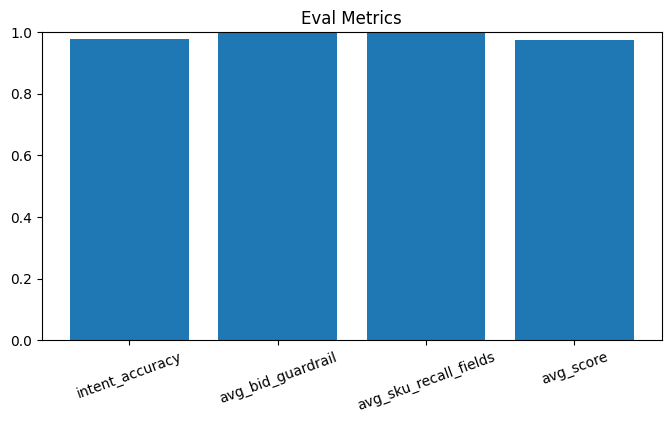

In [13]:
overall = eval_result["overall_metrics"]
metric_names = ["intent_accuracy", "avg_bid_guardrail", "avg_sku_recall_fields", "avg_score"]
plt.figure(figsize=(8, 4))
plt.bar(metric_names, [overall[name] for name in metric_names])
plt.xticks(rotation=20)
plt.title("Eval Metrics")
plt.ylim(0, 1)
plt.show()

图表说明：full_agent 的核心结构化指标接近稳定区间，课程评测使用 fail-under gate 防止只看单次 demo。

## 可视化：Ablation Avg Score

下图展示完整 Agent 与各消融模式的平均分差异。

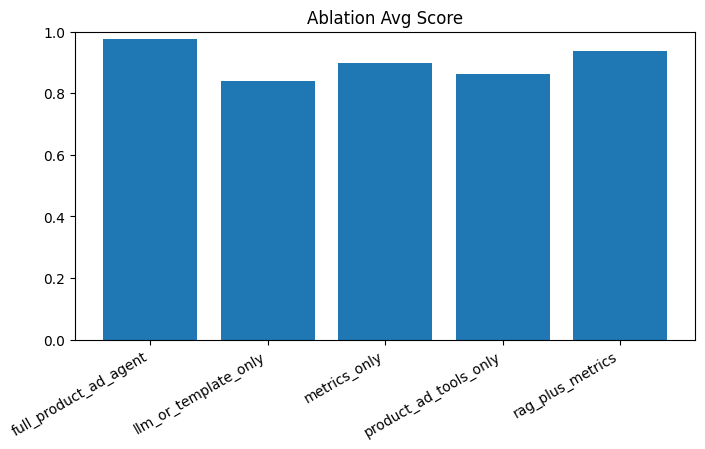

In [14]:
plt.figure(figsize=(8, 4))
plt.bar(ablation_df.index, ablation_df["avg_score"])
plt.xticks(rotation=30, ha="right")
plt.title("Ablation Avg Score")
plt.ylim(0, 1)
plt.show()

图表说明：完整链路保留 product_ad_tool、RAG、metrics 和 reflection，分数应高于只依赖模板或部分工具的模式。

## 可视化：Product Growth Signal

下图用简化视图展示 M001 候选商品的增长信号，真实排序仍以工具输出的 Product Growth Score 为准。

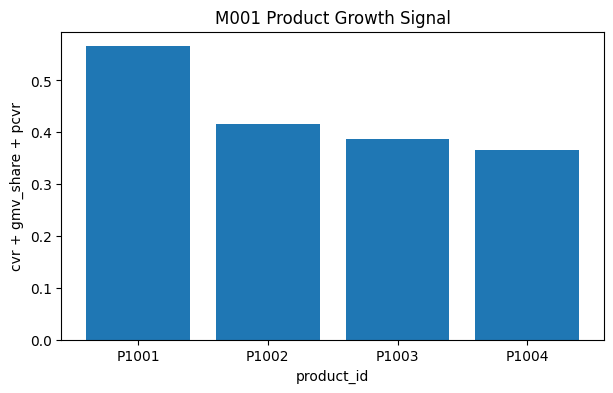

In [15]:
sku_plot_df = tables["local_ad_sku_candidates"].query("merchant_id == 'M001'").copy()
sku_plot_df["simple_growth_view"] = sku_plot_df["cvr"] + sku_plot_df["gmv_share"] + sku_plot_df["pcvr"]
plt.figure(figsize=(7, 4))
plt.bar(sku_plot_df["product_id"], sku_plot_df["simple_growth_view"])
plt.title("M001 Product Growth Signal")
plt.xlabel("product_id")
plt.ylabel("cvr + gmv_share + pcvr")
plt.show()

图表说明：P1001 的 CVR、GMV 占比和 PCVR 组合较高，但报告仍会同时提示退款率和 ROI 风险。

## 可视化：Bid Multiplier vs ROI

下图展示 synthetic 出价实验中 P1001 加价倍数与 ROI 的关系。

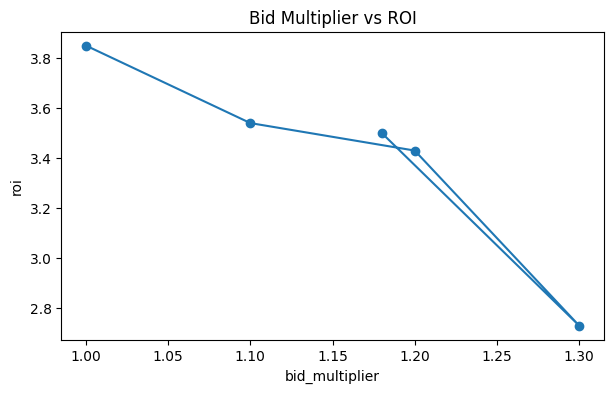

In [16]:
bid_plot_df = tables["ad_bid_experiments"].query("product_id == 'P1001'")
plt.figure(figsize=(7, 4))
plt.plot(bid_plot_df["bid_multiplier"], bid_plot_df["roi"], marker="o")
plt.title("Bid Multiplier vs ROI")
plt.xlabel("bid_multiplier")
plt.ylabel("roi")
plt.show()

图表说明：当目标 ROI 提高到 4.5 时，20% 加价即使有订单增长也会触发 risk/down_bid guardrail。

## 可视化：POI-level vs Product-level Ads

下图展示 synthetic baseline 中不同广告形态的 CTR、CVR 和 ROI。

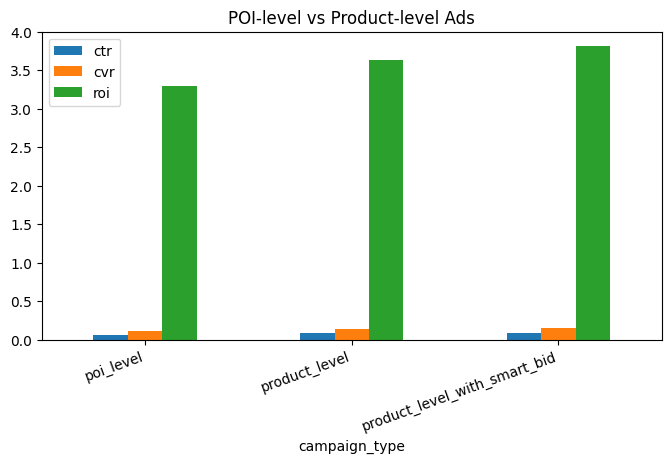

In [17]:
compare_plot_df = tables["poi_level_ads_baseline"].query("merchant_id == 'M001'")
compare_plot_df.set_index("campaign_type")[["ctr", "cvr", "roi"]].plot(kind="bar", figsize=(8, 4))
plt.title("POI-level vs Product-level Ads")
plt.xticks(rotation=20, ha="right")
plt.show()

图表说明：商品级广告在高意向 Query 下更容易提升 CTR/CVR，但必须配合 ROI 守护和供给/售后风险检查。